# Customer Health & Retention
**Project 2 — Revenue & GTM Analytics**

Analyzes customer health scores, churn risk, and Net Revenue Retention (NRR).

**Key questions:**
1. What is the health score distribution across the customer base?
2. How much revenue is at churn risk vs. expansion opportunity?
3. What is the NRR by segment?
4. Which accounts need immediate CS intervention?

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from mart_simulator import (
    build_stg_customer_success,
    build_fct_revenue,
    build_fct_customer_lifecycle,
    build_dim_account
)

pd.set_option('display.float_format', '{:,.2f}'.format)
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
cs       = build_stg_customer_success()
revenue  = build_fct_revenue()
lifecycle = build_fct_customer_lifecycle()
dim      = build_dim_account()

# Focus on paying customers with health data
customers = lifecycle[
    lifecycle['total_collected_usd'] > 0
].copy()

print(f'CS records:          {len(cs):,}')
print(f'Paying customers:    {len(customers):,}')
print(f'Churned accounts:    {lifecycle["is_churned"].sum():,}')
print(f'Expansion accounts:  {lifecycle["has_expansion"].sum():,}')

CS records:          697
Paying customers:    294
Churned accounts:    113
Expansion accounts:  332


## 2. Health Score Distribution

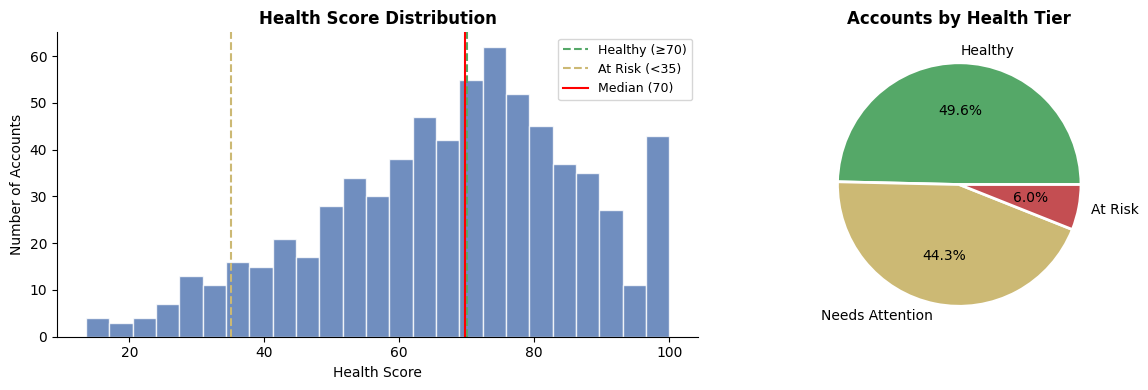

Health tier breakdown:


,Tier,Accounts,%
0,Healthy,346,49.6%
1,Needs Attention,309,44.3%
2,At Risk,42,6.0%


In [3]:
cs_valid = cs[cs['customer_health_score'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram
axes[0].hist(cs_valid['customer_health_score'], bins=25, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].axvline(70, color='#55A868', linestyle='--', linewidth=1.5, label='Healthy (≥70)')
axes[0].axvline(35, color='#CCB974', linestyle='--', linewidth=1.5, label='At Risk (<35)')
axes[0].axvline(cs_valid['customer_health_score'].median(), color='red', linestyle='-',
                linewidth=1.5, label=f'Median ({cs_valid["customer_health_score"].median():.0f})')
axes[0].set_xlabel('Health Score')
axes[0].set_ylabel('Number of Accounts')
axes[0].set_title('Health Score Distribution', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: health tier pie
tier_counts = cs['health_tier'].value_counts()
tier_colors = {'Healthy': '#55A868', 'Needs Attention': '#CCB974', 'At Risk': '#C44E52', 'Unknown': '#C0C0C0'}
colors = [tier_colors.get(t, '#C0C0C0') for t in tier_counts.index]
wedges, texts, autotexts = axes[1].pie(
    tier_counts, labels=tier_counts.index,
    autopct='%1.1f%%', colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Accounts by Health Tier', fontweight='bold')

plt.tight_layout()
plt.show()

print('Health tier breakdown:')
display(pd.DataFrame({
    'Tier': tier_counts.index,
    'Accounts': tier_counts.values,
    '%': tier_counts.values / tier_counts.sum()
}).style.format({'Accounts': '{:,}', '%': '{:.1%}'}))

## 3. Health Score by Segment

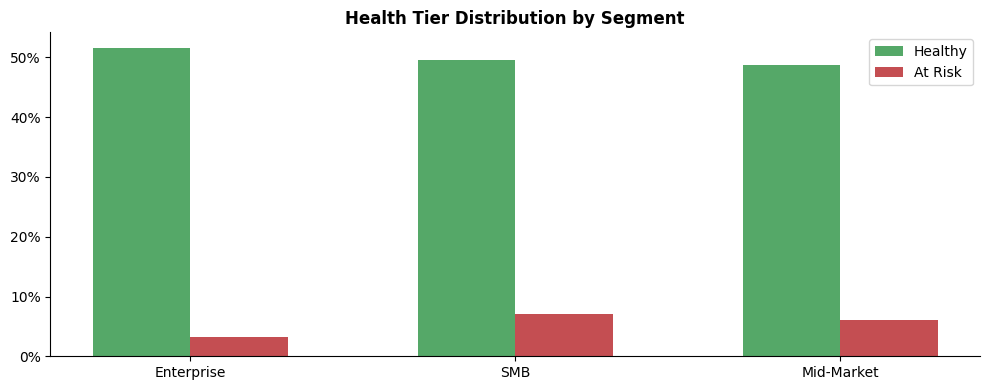

,segment,accounts,avg_health,median_health,pct_healthy,pct_at_risk,churned_count,expansion_count
0,Enterprise,124,70.0,70.8,51.6%,3.2%,13,63
2,SMB,325,67.5,69.8,49.5%,7.1%,52,152
1,Mid-Market,248,66.6,69.5,48.8%,6.0%,48,117


In [4]:
cs_with_seg = cs.merge(
    dim[['account_id', 'segment', 'revenue_model', 'total_collected_usd']],
    on='account_id', how='left'
)

seg_health = cs_with_seg.groupby('segment').agg(
    accounts=('account_id', 'nunique'),
    avg_health=('customer_health_score', 'mean'),
    median_health=('customer_health_score', 'median'),
    pct_healthy=('health_tier', lambda x: (x=='Healthy').sum()/len(x)),
    pct_at_risk=('health_tier', lambda x: (x=='At Risk').sum()/len(x)),
    churned_count=('is_churned', 'sum'),
    expansion_count=('has_expansion', 'sum'),
).reset_index().sort_values('avg_health', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(seg_health))
w = 0.3
ax.bar([i - w/2 for i in x], seg_health['pct_healthy'], w, color='#55A868', label='Healthy')
ax.bar([i + w/2 for i in x], seg_health['pct_at_risk'], w, color='#C44E52', label='At Risk')
ax.set_xticks(list(x))
ax.set_xticklabels(seg_health['segment'])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Health Tier Distribution by Segment', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

display(seg_health.style.format({
    'accounts': '{:,}',
    'avg_health': '{:.1f}',
    'median_health': '{:.1f}',
    'pct_healthy': '{:.1%}',
    'pct_at_risk': '{:.1%}',
    'churned_count': '{:,}',
    'expansion_count': '{:,}'
}).background_gradient(subset=['avg_health'], cmap='RdYlGn'))

## 4. NRR (Net Revenue Retention) Calculation

NRR = (Starting Revenue + Expansion − Churn) / Starting Revenue

A number > 100% means existing customers are growing faster than they churn.

In [5]:
# NRR at overall level using collected revenue
nrr_data = revenue.groupby(['segment', 'nrr_category']).agg(
    total_collected=('collected_amount_usd', 'sum')
).reset_index()

nrr_pivot = nrr_data.pivot_table(
    index='segment', columns='nrr_category', values='total_collected', fill_value=0
).reset_index()

for col in ['Churned', 'Expansion', 'Retained']:
    if col not in nrr_pivot.columns:
        nrr_pivot[col] = 0

# Simplified NRR: (Retained + Expansion) / (Retained + Expansion + Churned)
# Because churned customers produced $0 in collected revenue in this model,
# we use expansion_amount from CS for churn revenue proxy
cs_seg = cs.merge(dim[['account_id', 'segment']], on='account_id', how='left')

nrr_seg = cs_seg.groupby('segment').agg(
    total_accounts=('account_id', 'nunique'),
    churned_count=('is_churned', 'sum'),
    expansion_count=('has_expansion', 'sum'),
    total_expansion_amount=('expansion_amount', 'sum'),
    pct_churned=('is_churned', 'mean'),
    pct_expansion=('has_expansion', 'mean'),
).reset_index()

# Revenue-weighted NRR per segment
rev_seg = revenue.groupby('segment').agg(
    collected_retained=('collected_amount_usd', lambda x: x[revenue.loc[x.index,'nrr_category']=='Retained'].sum()),
    collected_expansion=('collected_amount_usd', lambda x: x[revenue.loc[x.index,'nrr_category']=='Expansion'].sum()),
).reset_index()

nrr_combined = nrr_seg.merge(rev_seg, on='segment', how='left')
nrr_combined['starting_revenue'] = nrr_combined['collected_retained'] + nrr_combined['collected_expansion']
nrr_combined['nrr'] = (
    (nrr_combined['collected_retained'] + nrr_combined['collected_expansion'] + nrr_combined['total_expansion_amount'])
    / nrr_combined['starting_revenue'].replace(0, np.nan)
)

print('=== NRR by Segment ===')
display(nrr_combined[['segment','total_accounts','churned_count','pct_churned','expansion_count','pct_expansion','total_expansion_amount','nrr']]
    .style
    .format({
        'total_accounts': '{:,}',
        'churned_count': '{:,}',
        'pct_churned': '{:.1%}',
        'expansion_count': '{:,}',
        'pct_expansion': '{:.1%}',
        'total_expansion_amount': '${:,.0f}',
        'nrr': '{:.0%}'
    })
    .background_gradient(subset=['nrr'], cmap='RdYlGn')
)

=== NRR by Segment ===


,segment,total_accounts,churned_count,pct_churned,expansion_count,pct_expansion,total_expansion_amount,nrr
0,Enterprise,124,13,10.5%,63,50.8%,"$102,940",104%
1,Mid-Market,248,48,19.4%,117,47.2%,"$257,284",111%
2,SMB,325,52,16.0%,152,46.8%,"$279,880",130%


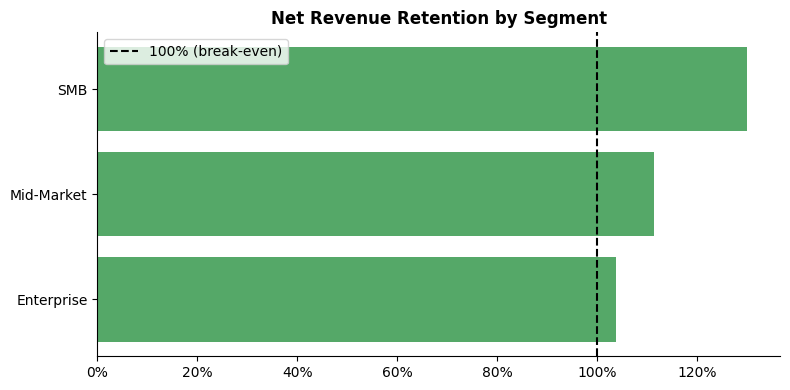

Overall NRR (approx): 111%


In [6]:
# Overall NRR
total_retained   = revenue.loc[revenue['nrr_category']=='Retained', 'collected_amount_usd'].sum()
total_expansion_rev = revenue.loc[revenue['nrr_category']=='Expansion', 'collected_amount_usd'].sum()
total_expansion_upsell = cs['expansion_amount'].sum()
starting_rev     = total_retained + total_expansion_rev
overall_nrr      = (starting_rev + total_expansion_upsell) / starting_rev if starting_rev > 0 else 0

# Visual
fig, ax = plt.subplots(figsize=(8, 4))
segs = nrr_combined.dropna(subset=['nrr']).sort_values('nrr', ascending=True)
colors = ['#55A868' if n >= 1 else '#C44E52' for n in segs['nrr']]
ax.barh(segs['segment'], segs['nrr'], color=colors)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='100% (break-even)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Net Revenue Retention by Segment', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Overall NRR (approx): {overall_nrr:.0%}')

## 5. Churn Reasons

Churned accounts: 113


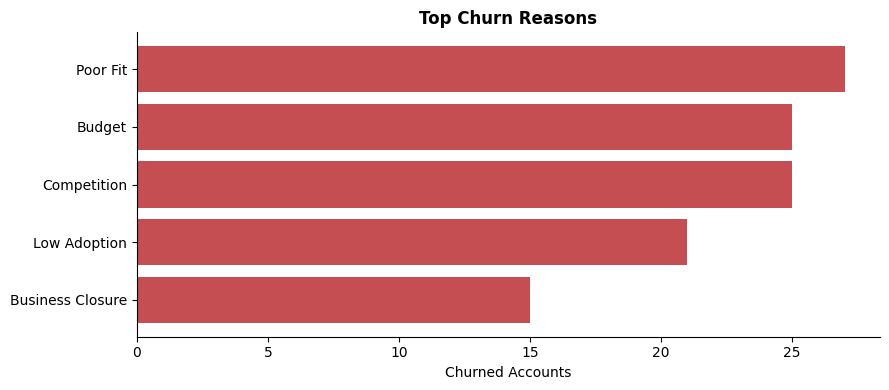

,reason,count,pct
0,Poor Fit,27,23.9%
1,Budget,25,22.1%
2,Competition,25,22.1%
3,Low Adoption,21,18.6%
4,Business Closure,15,13.3%


In [7]:
churned = cs[cs['is_churned']].copy()
print(f'Churned accounts: {len(churned):,}')

if 'churn_reason' in churned.columns and churned['churn_reason'].notna().any():
    churn_reasons = churned['churn_reason'].value_counts().reset_index()
    churn_reasons.columns = ['reason', 'count']
    churn_reasons['pct'] = churn_reasons['count'] / churn_reasons['count'].sum()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(churn_reasons['reason'][::-1].head(10), churn_reasons['count'][::-1].head(10), color='#C44E52')
    ax.set_xlabel('Churned Accounts')
    ax.set_title('Top Churn Reasons', fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    display(churn_reasons.head(10).style.format({'count': '{:,}', 'pct': '{:.1%}'}))
else:
    print('churn_reason not available or empty in this dataset.')

## 6. At-Risk Account Priority List

Accounts that need immediate CS outreach: low health score + upcoming renewal.

In [8]:
at_risk_accounts = (
    lifecycle[
        (lifecycle['health_tier'].isin(['At Risk', 'Needs Attention']))
        & (lifecycle['is_churned'].fillna(False) == False)
        & (lifecycle['total_collected_usd'] > 0)
    ]
    # Only pull columns from cs that aren't already in lifecycle
    .merge(
        cs[['account_id', 'renewal_date', 'days_to_renewal', 'churn_reason']],
        on='account_id', how='left'
    )
    .sort_values(['customer_health_score', 'days_to_renewal'])
)

print(f'At-risk accounts (paying, not churned, low health): {len(at_risk_accounts):,}')
print()

priority_cols = [
    'account_id', 'account_name', 'segment', 'health_tier',
    'customer_health_score', 'days_to_renewal', 'total_collected_usd', 'renewal_status'
]
available_cols = [c for c in priority_cols if c in at_risk_accounts.columns]

display(
    at_risk_accounts[available_cols].head(15)
    .style
    .format({
        'customer_health_score': '{:.0f}',
        'days_to_renewal': '{:.0f}',
        'total_collected_usd': '${:,.0f}'
    })
    .background_gradient(subset=['customer_health_score'], cmap='RdYlGn')
)

At-risk accounts (paying, not churned, low health): 70



,account_id,account_name,segment,health_tier,customer_health_score,days_to_renewal,total_collected_usd,renewal_status
67,ACC_00069,Vertex Partners 0069,SMB,At Risk,26,-876,"$5,122",At Risk
29,ACC_00276,BluePeak Partners 0276,SMB,At Risk,30,-734,"$9,886",At Risk
33,ACC_00776,Pioneer Technologies 0776,Enterprise,At Risk,32,-716,"$93,504",At Risk
28,ACC_00214,Harbor Networks 0214,Mid-Market,At Risk,33,-671,"$51,798",At Risk
69,ACC_00736,Nova Solutions 0736,Mid-Market,Needs Attention,37,-312,"$26,688",Needs Attention
61,ACC_00072,BluePeak Solutions 0072,SMB,Needs Attention,41,-683,$940,Needs Attention
10,ACC_00133,BluePeak Systems 0133,Mid-Market,Needs Attention,41,-687,"$10,979",Needs Attention
58,ACC_00531,Atlas Systems 0531,Mid-Market,Needs Attention,42,-872,"$14,615",Needs Attention
2,ACC_00814,Summit Systems 0814,Mid-Market,Needs Attention,43,-707,"$4,377",Needs Attention
43,ACC_00084,Pioneer Partners 0084,SMB,Needs Attention,43,-655,"$17,286",Needs Attention


## 7. Health Score vs. Expansion

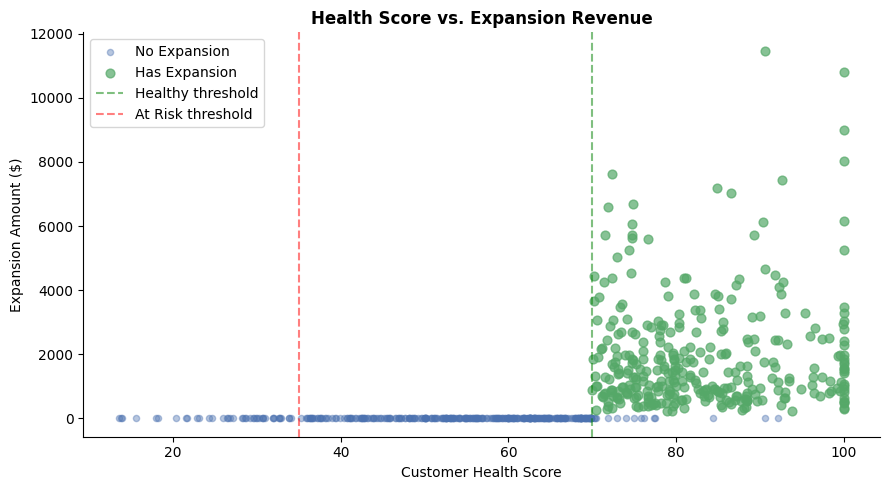

Correlation (health score vs expansion amount): r = 0.512


In [9]:
expansion_data = cs[cs['customer_health_score'] > 0].copy()

fig, ax = plt.subplots(figsize=(9, 5))

has_exp = expansion_data[expansion_data['has_expansion']]
no_exp  = expansion_data[~expansion_data['has_expansion']]

ax.scatter(no_exp['customer_health_score'], no_exp['expansion_amount'],
           alpha=0.4, s=20, color='#4C72B0', label='No Expansion')
ax.scatter(has_exp['customer_health_score'], has_exp['expansion_amount'],
           alpha=0.7, s=40, color='#55A868', label='Has Expansion')

ax.axvline(70, color='green', linestyle='--', alpha=0.5, label='Healthy threshold')
ax.axvline(35, color='red', linestyle='--', alpha=0.5, label='At Risk threshold')
ax.set_xlabel('Customer Health Score')
ax.set_ylabel('Expansion Amount ($)')
ax.set_title('Health Score vs. Expansion Revenue', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

corr = expansion_data['customer_health_score'].corr(expansion_data['expansion_amount'])
print(f'Correlation (health score vs expansion amount): r = {corr:.3f}')

## 8. Summary — Key Findings

In [10]:
pct_healthy     = (cs['health_tier'] == 'Healthy').mean()
pct_at_risk_t   = (cs['health_tier'] == 'At Risk').mean()
pct_churned     = cs['is_churned'].mean()
pct_expansion   = cs['has_expansion'].mean()
total_exp       = cs['expansion_amount'].sum()
median_score    = cs[cs['customer_health_score'] > 0]['customer_health_score'].median()

print('=' * 55)
print('  CUSTOMER HEALTH — KEY FINDINGS')
print('=' * 55)
print(f'  CS records:            {len(cs):,}')
print(f'  Median health score:   {median_score:.0f}/100')
print(f'  Healthy (≥70):         {pct_healthy:.1%} of accounts')
print(f'  Needs Attention (35-70): {(cs["health_tier"]=="Needs Attention").mean():.1%}')
print(f'  At Risk (<35):         {pct_at_risk_t:.1%} of accounts')
print(f'  Churned:               {pct_churned:.1%} of accounts ({cs["is_churned"].sum():,} accounts)')
print(f'  With expansion:        {pct_expansion:.1%} of accounts')
print(f'  Total expansion ARR:   ${total_exp:,.0f}')
print(f'  Overall NRR (approx):  {overall_nrr:.0%}')
print(f'  At-risk + paying:      {len(at_risk_accounts):,} accounts need CS outreach')
print('=' * 55)
print('\ndbt models: stg_customer_success → dim_account → fct_revenue, fct_customer_lifecycle')

  CUSTOMER HEALTH — KEY FINDINGS
  CS records:            697
  Median health score:   70/100
  Healthy (≥70):         49.6% of accounts
  Needs Attention (35-70): 44.3%
  At Risk (<35):         6.0% of accounts
  Churned:               16.2% of accounts (113 accounts)
  With expansion:        47.6% of accounts
  Total expansion ARR:   $640,104
  Overall NRR (approx):  111%
  At-risk + paying:      70 accounts need CS outreach

dbt models: stg_customer_success → dim_account → fct_revenue, fct_customer_lifecycle
